# Spotify Million Playlist Dataset Analysis
This notebook performs a comprehensive data analysis of the Spotify Million Playlist Dataset using PySpark. We will explore playlist characteristics, top artists, tracks, and track durations.

In [ ]:
import os
import pyspark.sql.functions as F
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("SpotifyDataAnalysis") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.local.dir", "D:\\spark-temp") \
    .getOrCreate()

print("Spark Session created successfully.")

Spark Session created successfully.


## 1. Data Loading
We read the JSON files from HDFS using PySpark. We must specify `.option("multiLine", "true")` because the standard JSON format here spans multiple lines per object.

In [11]:
file_path = "/home/jovyan/work/dataset/data/"
# Read multi-line JSONs from HDFS
# df = spark.read.option("multiLine", "true").json(file_path)

df = spark.read \
    .option("multiline", "true") \
    .option("samplingRatio", "0.1") \
    .json(file_path)

print("Dataset Top-Level Schema:")
df.printSchema()

Dataset Top-Level Schema:
root
 |-- info: struct (nullable = true)
 |    |-- generated_on: string (nullable = true)
 |    |-- slice: string (nullable = true)
 |    |-- version: string (nullable = true)
 |-- playlists: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- collaborative: string (nullable = true)
 |    |    |-- description: string (nullable = true)
 |    |    |-- duration_ms: long (nullable = true)
 |    |    |-- modified_at: long (nullable = true)
 |    |    |-- name: string (nullable = true)
 |    |    |-- num_albums: long (nullable = true)
 |    |    |-- num_artists: long (nullable = true)
 |    |    |-- num_edits: long (nullable = true)
 |    |    |-- num_followers: long (nullable = true)
 |    |    |-- num_tracks: long (nullable = true)
 |    |    |-- pid: long (nullable = true)
 |    |    |-- tracks: array (nullable = true)
 |    |    |    |-- element: struct (containsNull = true)
 |    |    |    |    |-- album_name: string (nullable

In [10]:
# file_path = "/home/jovyan/work/dataset/data/mpd.slice.0-999.json"

# df = spark.read.option("multiline", "true").json(file_path)

# df.show(5)

+--------------------+--------------------+
|                info|           playlists|
+--------------------+--------------------+
|{2017-12-03 08:41...|[{false, NULL, 11...|
+--------------------+--------------------+



## 2. Data Flattening
The input data has nested arrays. We will use `explode()` to flatten the playlists so we can analyze them at the playlist level, and further explode to analyze all at the track level.

In [12]:
# Explode the playlists array to get playlist rows
df_playlists = df.select(F.explode("playlists").alias("playlist"))

# Extract playlist-level attributes
playlists = df_playlists.select(
    F.col("playlist.pid").alias("playlist_id"),
    F.col("playlist.name").alias("playlist_name"),
    F.col("playlist.num_tracks").alias("num_tracks"),
    F.col("playlist.num_albums").alias("num_albums"),
    F.col("playlist.num_followers").alias("num_followers"),
    F.col("playlist.collaborative").alias("collaborative")
)

# Cache datasets heavily used in calculation
playlists.cache()

print(f"Total Playlists retrieved: {playlists.count()}")
playlists.show(5, truncate=False)

Total Playlists retrieved: 1000000
+-----------+-------------+----------+----------+-------------+-------------+
|playlist_id|playlist_name|num_tracks|num_albums|num_followers|collaborative|
+-----------+-------------+----------+----------+-------------+-------------+
|834000     |pump         |36        |32        |2            |false        |
|834001     |Summer 16    |117       |89        |2            |false        |
|834002     |old school   |126       |95        |2            |false        |
|834003     |pumped       |89        |57        |1            |false        |
|834004     |Stress free  |95        |76        |1            |false        |
+-----------+-------------+----------+----------+-------------+-------------+
only showing top 5 rows



Now we explode the tracks within each playlist to obtain a flat table of all tracks.

In [13]:
# Explode the tracks array
df_tracks_exploded = df_playlists.select(
    F.col("playlist.pid").alias("playlist_id"),
    F.explode("playlist.tracks").alias("track")
)

# Extract track attributes
tracks = df_tracks_exploded.select(
    F.col("playlist_id"),
    F.col("track.track_uri"),
    F.col("track.track_name"),
    F.col("track.artist_uri"),
    F.col("track.artist_name"),
    F.col("track.album_uri"),
    F.col("track.album_name"),
    F.col("track.duration_ms")
)

tracks.cache()

print(f"Total Tracks processed (includes duplicates across playlists): {tracks.count()}")
tracks.show(5, truncate=False)

Total Tracks processed (includes duplicates across playlists): 66346428
+-----------+------------------------------------+----------------------+-------------------------------------+-------------+------------------------------------+---------------------+-----------+
|playlist_id|track_uri                           |track_name            |artist_uri                           |artist_name  |album_uri                           |album_name           |duration_ms|
+-----------+------------------------------------+----------------------+-------------------------------------+-------------+------------------------------------+---------------------+-----------+
|834000     |spotify:track:6f8rLbp7EyoDifNpvBmzyw|What's up (feat. 1st) |spotify:artist:246dkjvS1zLTtiykXe5h60|Post Malone  |spotify:album:6Nu7TPANghuXJD6DrIddaP|What's up (feat. 1st)|290533     |
|834000     |spotify:track:3pXF1nA74528Edde4of9CC|Don't                 |spotify:artist:2EMAnMvWE2eb56ToJVfCWs|Bryson Tiller|spotify:album:6

## 3. Exploratory Data Analysis (EDA)
Let's dive into some metrics.

### 3.1 Most Popular Artists
Identifying artists with the highest inclusion count across all user playlists.

In [14]:
top_artists = tracks.groupBy("artist_name") \
    .count() \
    .orderBy(F.desc("count"))

print("Top 10 Most Popular Artists:")
top_artists.show(10, truncate=False)

Top 10 Most Popular Artists:
+--------------+------+
|artist_name   |count |
+--------------+------+
|Drake         |847160|
|Kanye West    |413297|
|Kendrick Lamar|353624|
|Rihanna       |339570|
|The Weeknd    |316603|
|Eminem        |294667|
|Ed Sheeran    |272116|
|Future        |250734|
|Justin Bieber |243119|
|J. Cole       |241560|
+--------------+------+
only showing top 10 rows



### 3.2 Most Popular Tracks
Identifying identical tracks occurring in the most playlists.

In [15]:
top_tracks = tracks.groupBy("track_name", "artist_name") \
    .count() \
    .orderBy(F.desc("count"))

print("Top 10 Most Popular Tracks:")
top_tracks.show(10, truncate=False)

Top 10 Most Popular Tracks:
+-----------------------------------+----------------+-----+
|track_name                         |artist_name     |count|
+-----------------------------------+----------------+-----+
|HUMBLE.                            |Kendrick Lamar  |46574|
|One Dance                          |Drake           |43447|
|Broccoli (feat. Lil Yachty)        |DRAM            |41309|
|Closer                             |The Chainsmokers|41079|
|Congratulations                    |Post Malone     |39987|
|Caroline                           |Aminé           |35202|
|iSpy (feat. Lil Yachty)            |KYLE            |35138|
|Bad and Boujee (feat. Lil Uzi Vert)|Migos           |34999|
|Location                           |Khalid          |34990|
|XO TOUR Llif3                      |Lil Uzi Vert    |34922|
+-----------------------------------+----------------+-----+
only showing top 10 rows



### 3.3 Averages Across Playlists

In [16]:
playlist_stats = playlists.select(
    F.avg("num_tracks").alias("avg_tracks_per_playlist"),
    F.avg("num_albums").alias("avg_albums_per_playlist"),
    F.avg("num_followers").alias("avg_followers_per_playlist")
)

print("Playlist Metrics Averages:")
playlist_stats.show()

Playlist Metrics Averages:
+-----------------------+-----------------------+--------------------------+
|avg_tracks_per_playlist|avg_albums_per_playlist|avg_followers_per_playlist|
+-----------------------+-----------------------+--------------------------+
|              66.346428|              49.597278|                  2.597746|
+-----------------------+-----------------------+--------------------------+



### 3.4 Feature Statistics - Track Durations
Analyze duration in minutes across all tracks.

In [17]:
# Convert duration from ms to minutes
duration_df = tracks.withColumn("duration_minutes", F.col("duration_ms") / 60000)

duration_stats = duration_df.select(
    F.min("duration_minutes").alias("min_duration_mins"),
    F.max("duration_minutes").alias("max_duration_mins"),
    F.avg("duration_minutes").alias("avg_duration_mins")
)

print("Track Duration Statistics (Mins):")
duration_stats.show()

Track Duration Statistics (Mins):
+--------------------+------------------+-----------------+
|   min_duration_mins| max_duration_mins|avg_duration_mins|
+--------------------+------------------+-----------------+
|-1.66666666666666...|345.74291666666664|3.913719073340897|
+--------------------+------------------+-----------------+



## 4. Visualizations
Convert aggregate queries using Pandas internally to create quick visualizations using `matplotlib`.

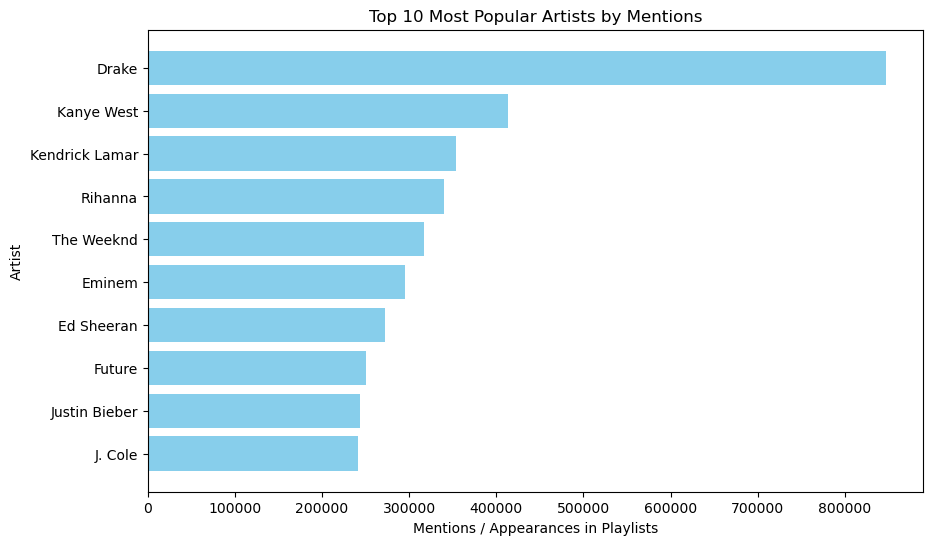

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Fetch top 10 artists back to local Pandas dataframe (this is fast because data is aggregated!)
top_artists_pd = top_artists.limit(10).toPandas()

plt.figure(figsize=(10,6))
plt.barh(top_artists_pd['artist_name'], top_artists_pd['count'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 10 Most Popular Artists by Mentions')
plt.xlabel('Mentions / Appearances in Playlists')
plt.ylabel('Artist')
plt.show()

In [19]:
top_albums = tracks.groupBy("album_name", "artist_name") \
    .count() \
    .orderBy(F.desc("count"))

print("Top 10 Most Popular Albums:")
top_albums.show(10, truncate=False)

Top 10 Most Popular Albums:
+-------------------------+-----------------+------+
|album_name               |artist_name      |count |
+-------------------------+-----------------+------+
|Views                    |Drake            |208533|
|Stoney                   |Post Malone      |156488|
|More Life                |Drake            |141701|
|DAMN.                    |Kendrick Lamar   |141638|
|Beauty Behind The Madness|The Weeknd       |136517|
|Coloring Book            |Chance The Rapper|133050|
|American Teen            |Khalid           |120946|
|Culture                  |Migos            |120017|
|Purpose                  |Justin Bieber    |114885|
|The Life Of Pablo        |Kanye West       |113024|
+-------------------------+-----------------+------+
only showing top 10 rows



In [24]:
top_followed_playlists = playlists.select("playlist_name", "num_followers", "num_tracks") \
    .orderBy(F.desc("num_followers"))

print("Top 10 Most Followed Playlists:")
top_followed_playlists.show(10, truncate=False)

Top 10 Most Followed Playlists:
+------------------+-------------+----------+
|playlist_name     |num_followers|num_tracks|
+------------------+-------------+----------+
|That's What I Like|71643        |39        |
|Breaking Bad      |53519        |106       |
|One Tree Hill     |45942        |111       |
|My Little Pony    |31539        |85        |
|Q1                |27830        |81        |
|Jack's Playlist   |23500        |29        |
|Rock Hits         |22102        |56        |
|TOP POP           |15842        |52        |
|FARRUKO           |15123        |13        |
|Wiz Khalifa       |14812        |115       |
+------------------+-------------+----------+
only showing top 10 rows



In [20]:
playlist_size_dist = playlists.groupBy("num_tracks") \
    .count() \
    .orderBy("num_tracks")

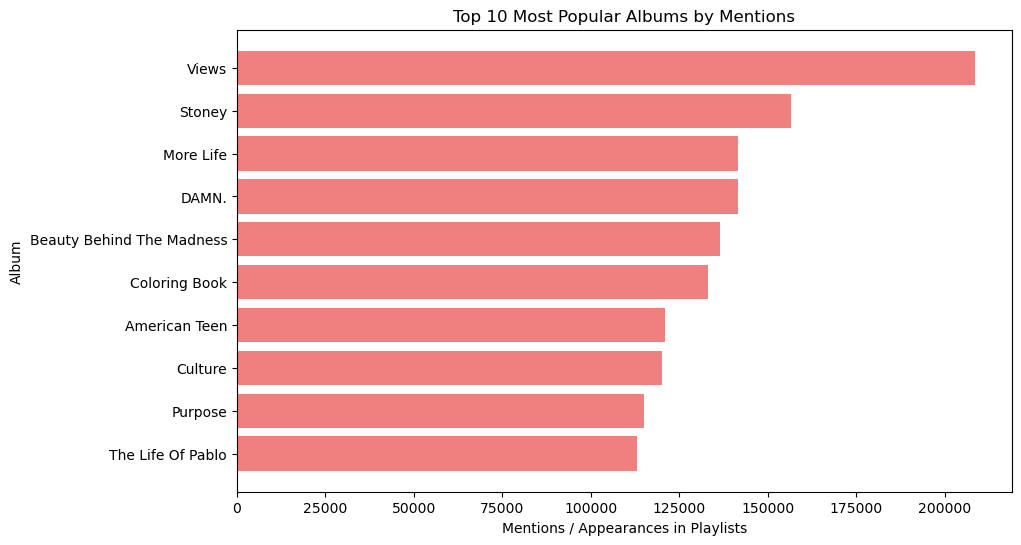

In [21]:
# Top 10 Albums Visualization
top_albums_pd = top_albums.limit(10).toPandas()

plt.figure(figsize=(10,6))
plt.barh(top_albums_pd['album_name'], top_albums_pd['count'], color='lightcoral')
plt.gca().invert_yaxis()
plt.title('Top 10 Most Popular Albums by Mentions')
plt.xlabel('Mentions / Appearances in Playlists')
plt.ylabel('Album')
plt.show()

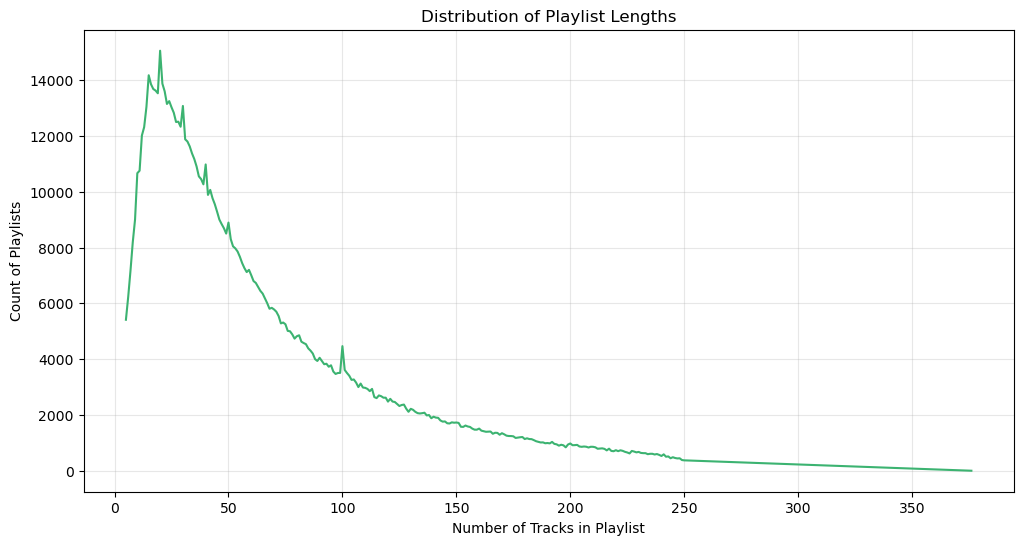

In [22]:
# Distribution of Tracks per Playlist Visualization
playlist_size_pd = playlist_size_dist.toPandas()

plt.figure(figsize=(12,6))
plt.plot(playlist_size_pd['num_tracks'], playlist_size_pd['count'], color='mediumseagreen')
plt.title('Distribution of Playlist Lengths')
plt.xlabel('Number of Tracks in Playlist')
plt.ylabel('Count of Playlists')
plt.grid(alpha=0.3)
plt.show()

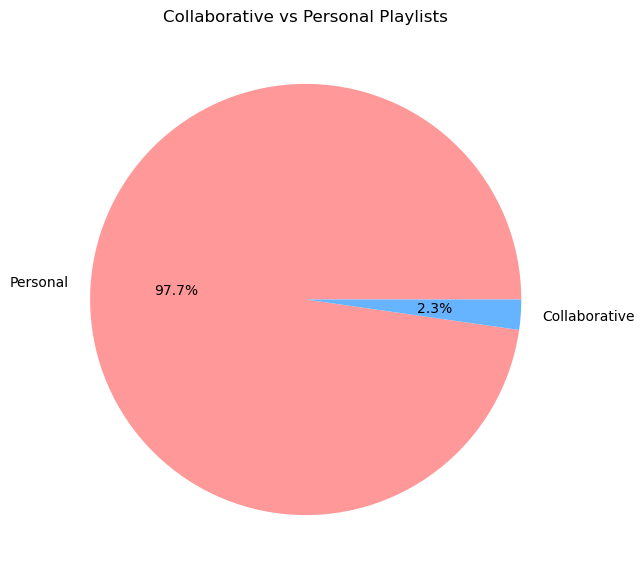

In [23]:
# Collaborative vs Non-Collaborative Playlists
collab_stats = playlists.groupBy("collaborative").count().toPandas()

plt.figure(figsize=(7,7))
plt.pie(collab_stats['count'], labels=collab_stats['collaborative'].apply(lambda x: "Collaborative" if x == "true" else "Personal"), autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Collaborative vs Personal Playlists')
plt.show()

In [ ]:
# def recommend_songs(target_track_name, target_artist_name=None, num_recommendations=10):
#     print(f"Finding recommendations for: '{target_track_name}'" + (f" by {target_artist_name}" if target_artist_name else ""))
    
#     if target_artist_name:
#         target_playlists = tracks.filter((F.col("track_name") == target_track_name) & (F.col("artist_name") == target_artist_name))
#     else:
#         target_playlists = tracks.filter(F.col("track_name") == target_track_name)
        
#     target_playlist_ids = target_playlists.select("playlist_id").distinct()
    
#     # We use a broadcast join because target_playlist_ids is significantly smaller than the tracks dataframe.
#     # This speeds up the execution considerably.
#     co_occurring_tracks = tracks.join(F.broadcast(target_playlist_ids), on="playlist_id", how="inner")
    
#     if target_artist_name:
#         recommendations = co_occurring_tracks.filter(~((F.col("track_name") == target_track_name) & (F.col("artist_name") == target_artist_name)))
#     else:
#         recommendations = co_occurring_tracks.filter(~(F.col("track_name") == target_track_name))
        
#     top_recommendations = recommendations.groupBy("track_name", "artist_name") \
#         .count() \
#         .orderBy(F.desc("count")) \
#         .limit(num_recommendations)
        
#     return top_recommendations


In [26]:
from pyspark.sql import functions as F

def recommend_tracks(tracks, target_track_name, target_artist_name=None, num_recommendations=10):
    
    # Filter rows matching the target track (and optionally artist)
    if target_artist_name:
        target_df = tracks.filter(
            (F.col("track_name") == target_track_name) & 
            (F.col("artist_name") == target_artist_name)
        )
    else:
        target_df = tracks.filter(
            F.col("track_name") == target_track_name
        )

    # Total playlists containing the target track
    total_target_playlists = target_df.select("playlist_id").distinct().count()

    # Get playlist IDs
    target_playlists = target_df.select("playlist_id").distinct()

    # Get all tracks from those playlists
    candidate_tracks = tracks.join(target_playlists, on="playlist_id", how="inner")

    # Remove the original track
    if target_artist_name:
        candidate_tracks = candidate_tracks.filter(
            ~((F.col("track_name") == target_track_name) & 
              (F.col("artist_name") == target_artist_name))
        )
    else:
        candidate_tracks = candidate_tracks.filter(
            F.col("track_name") != target_track_name
        )

    # Count co-occurrence + playlist support
    recommendations = candidate_tracks.groupBy("track_name", "artist_name") \
        .agg(
            F.count("*").alias("co_occurrence"),
            F.countDistinct("playlist_id").alias("playlist_support")
        )

    # Add normalized score (VERY IMPORTANT)
    recommendations = recommendations.withColumn(
        "confidence_score",
        F.col("playlist_support") / F.lit(total_target_playlists)
    )

    # Optional: reduce popularity bias
    track_popularity = tracks.groupBy("track_name", "artist_name") \
        .agg(F.countDistinct("playlist_id").alias("global_popularity"))

    recommendations = recommendations.join(
        track_popularity,
        on=["track_name", "artist_name"],
        how="left"
    )

    # Final ranking
    recommendations = recommendations.orderBy(
        F.desc("confidence_score"),
        F.desc("co_occurrence")
    ).limit(num_recommendations)

    return recommendations

In [ ]:
rec = recommend_tracks(tracks, "Shape of You")

rec.coalesce(1).write.mode("overwrite").option("header", True).csv("output/recommendations")
